In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning


In [3]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/data/raw

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/raw


In [4]:
!ls

BBBC021_v1_images_Week10_40111.zip  Week2_24381  Week5_28901  Week7_34641
BBBC021_v1_images_Week10_40115.zip  Week2_24401  Week5_28921  Week7_34661
text.txt			    Week3_25421  Week5_28961  Week7_34681
Week10_40111			    Week3_25441  Week5_29301  Week8_38203
Week10_40115			    Week3_25461  Week5_29321  Week8_38221
Week1_22123			    Week3_25681  Week5_29341  Week8_38241
Week1_22141			    Week3_25701  Week6_31641  Week8_38341
Week1_22161			    Week3_25721  Week6_31661  Week8_38342
Week1_22361			    Week4_27481  Week6_31681  Week9_39206
Week1_22401			    Week4_27521  Week6_32061  Week9_39221
Week2_24121			    Week4_27542  Week6_32121  Week9_39222
Week2_24141			    Week4_27801  Week6_32161  Week9_39282
Week2_24161			    Week4_27821  Week7_34341  Week9_39283
Week2_24361			    Week4_27861  Week7_34381  Week9_39301


Imports

In [8]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

%matplotlib inline

Data Paths

In [9]:
DATA_DIR = "data/raw"
METADATA_PATH = "data/metadata/BBBC021_v1_image.csv"

print("Plates:", os.listdir(DATA_DIR))

Plates: ['Week10_40115', 'text.txt', 'Week2_24121', 'Week2_24141', 'Week2_24161', 'Week2_24361', 'Week2_24381', 'Week2_24401', 'Week1_22123', 'Week1_22141', 'Week1_22161', 'Week1_22361', 'Week1_22401', 'Week3_25421', 'Week3_25441', 'Week3_25721', 'Week3_25461', 'Week3_25681', 'Week3_25701', 'Week4_27481', 'Week4_27521', 'Week4_27542', 'Week4_27801', 'Week4_27821', 'Week4_27861', 'Week5_28901', 'Week5_28921', 'Week5_28961', 'Week5_29301', 'Week5_29321', 'Week5_29341', 'Week6_31641', 'Week6_31661', 'Week6_31681', 'Week6_32061', 'Week6_32121', 'Week6_32161', 'Week7_34341', 'Week7_34381', 'Week7_34641', 'Week7_34661', 'Week7_34681', 'Week8_38203', 'Week8_38221', 'Week8_38241', 'Week8_38341', 'Week8_38342', 'Week9_39206', 'Week9_39221', 'Week9_39222', 'Week9_39282', 'Week9_39283', 'Week9_39301', 'Week10_40111']


Load Meta Data

In [10]:
metadata = pd.read_csv(METADATA_PATH)
metadata.head()

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,Image_Metadata_Plate_DAPI,Image_Metadata_Well_DAPI,Replicate,Image_Metadata_Compound,Image_Metadata_Concentration
0,4,233,G10_s1_w1BEDC2073-A983-4B98-95E9-84466707A25D.tif,Week4/Week4_27481,G10_s1_w2DCEC82F3-05F7-4F2F-B779-C5DF9698141E.tif,Week4/Week4_27481,G10_s1_w43CD51CBC-2370-471F-BA01-EE250B14B3C8.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
1,4,234,G10_s2_w11C3B9BCC-E48F-4C2F-9D31-8F46D8B5B972.tif,Week4/Week4_27481,G10_s2_w2570437EF-C8DC-4074-8D63-7FA3A7271FEE.tif,Week4/Week4_27481,G10_s2_w400B21F33-BDAB-4363-92C2-F4FB7545F08C.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
2,4,235,G10_s3_w1F4FCE330-C71C-4CA3-9815-EAF9B9876EB5.tif,Week4/Week4_27481,G10_s3_w2194A9AC7-369B-4D84-99C0-DA809B0042B8.tif,Week4/Week4_27481,G10_s3_w4E0452054-9FC1-41AB-8C5B-D0ACD058991F.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
3,4,236,G10_s4_w1747818B4-FFA7-40EE-B0A0-6A5974AF2644.tif,Week4/Week4_27481,G10_s4_w298D4652F-B5BF-49F2-BE51-8149DF83EAFD.tif,Week4/Week4_27481,G10_s4_w42648D36D-6B77-41CD-B520-6E4C533D9ABC.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
4,4,473,G10_s1_w10034568D-CC12-43C3-93A9-DC3782099DD3.tif,Week4/Week4_27521,G10_s1_w2A29ED14B-952C-4BA1-89B9-4F92B6DADEB4.tif,Week4/Week4_27521,G10_s1_w4DAA2E9D1-F6E9-45FA-ADC0-D341B647A680.tif,Week4/Week4_27521,Week4_27521,G10,2,5-fluorouracil,0.003


In [11]:
#Fixing the file data
# function
def fix_path(pathname):
    return pathname.split("/")[-1]

# columns to apply fix
columns_to_fix = [
    "Image_PathName_DAPI",
    "Image_PathName_Tubulin",
    "Image_PathName_Actin"
]

# apply function
for col in columns_to_fix:
    metadata[col] = metadata[col].apply(fix_path)

# save cleaned file
#metadata.to_csv("cleaned_metadata.csv", index=False)

#print("File saved successfully.")

In [12]:
metadata.head(2)

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,Image_Metadata_Plate_DAPI,Image_Metadata_Well_DAPI,Replicate,Image_Metadata_Compound,Image_Metadata_Concentration
0,4,233,G10_s1_w1BEDC2073-A983-4B98-95E9-84466707A25D.tif,Week4_27481,G10_s1_w2DCEC82F3-05F7-4F2F-B779-C5DF9698141E.tif,Week4_27481,G10_s1_w43CD51CBC-2370-471F-BA01-EE250B14B3C8.tif,Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
1,4,234,G10_s2_w11C3B9BCC-E48F-4C2F-9D31-8F46D8B5B972.tif,Week4_27481,G10_s2_w2570437EF-C8DC-4074-8D63-7FA3A7271FEE.tif,Week4_27481,G10_s2_w400B21F33-BDAB-4363-92C2-F4FB7545F08C.tif,Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003


In [13]:
#Creating a subset of the metadata that corresponds with the subset of the data that will be worked on
subset_metadata = metadata[
    metadata["Image_Metadata_Plate_DAPI"].isin([
        'Week1_22123', 'Week1_22141', 'Week1_22161', 'Week1_22361', 'Week1_22381', 'Week1_22401',
        'Week2_24121', 'Week2_24141', 'Week2_24161', 'Week2_24361', 'Week2_24381', 'Week2_24401',
        'Week3_25421', 'Week3_25441', 'Week3_25721', 'Week3_25461', 'Week3_25681', 'Week3_25701',
        'Week4_27481', 'Week4_27521', 'Week4_27542', 'Week4_27801', 'Week4_27821', 'Week4_27861',
        'Week5_28901', 'Week5_28921', 'Week5_28961', 'Week5_29301', 'Week5_29321', 'Week5_29341',
        'Week6_31641', 'Week6_31661', 'Week6_31681', 'Week6_32061', 'Week6_32121', 'Week6_32161',
        'Week7_34341', 'Week7_34381', 'Week7_34641', 'Week7_34661', 'Week7_34681',
        'Week8_38203', 'Week8_38221', 'Week8_38241', 'Week8_38341', 'Week8_38342',
        'Week9_39206', 'Week9_39221', 'Week9_39222', 'Week9_39282', 'Week9_39283', 'Week9_39301',
        'Week10_40111', 'Week10_40115', 'Week10_40119'
    ])
]

subset_metadata.head()

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,Image_Metadata_Plate_DAPI,Image_Metadata_Well_DAPI,Replicate,Image_Metadata_Compound,Image_Metadata_Concentration
0,4,233,G10_s1_w1BEDC2073-A983-4B98-95E9-84466707A25D.tif,Week4_27481,G10_s1_w2DCEC82F3-05F7-4F2F-B779-C5DF9698141E.tif,Week4_27481,G10_s1_w43CD51CBC-2370-471F-BA01-EE250B14B3C8.tif,Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
1,4,234,G10_s2_w11C3B9BCC-E48F-4C2F-9D31-8F46D8B5B972.tif,Week4_27481,G10_s2_w2570437EF-C8DC-4074-8D63-7FA3A7271FEE.tif,Week4_27481,G10_s2_w400B21F33-BDAB-4363-92C2-F4FB7545F08C.tif,Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
2,4,235,G10_s3_w1F4FCE330-C71C-4CA3-9815-EAF9B9876EB5.tif,Week4_27481,G10_s3_w2194A9AC7-369B-4D84-99C0-DA809B0042B8.tif,Week4_27481,G10_s3_w4E0452054-9FC1-41AB-8C5B-D0ACD058991F.tif,Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
3,4,236,G10_s4_w1747818B4-FFA7-40EE-B0A0-6A5974AF2644.tif,Week4_27481,G10_s4_w298D4652F-B5BF-49F2-BE51-8149DF83EAFD.tif,Week4_27481,G10_s4_w42648D36D-6B77-41CD-B520-6E4C533D9ABC.tif,Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
4,4,473,G10_s1_w10034568D-CC12-43C3-93A9-DC3782099DD3.tif,Week4_27521,G10_s1_w2A29ED14B-952C-4BA1-89B9-4F92B6DADEB4.tif,Week4_27521,G10_s1_w4DAA2E9D1-F6E9-45FA-ADC0-D341B647A680.tif,Week4_27521,Week4_27521,G10,2,5-fluorouracil,0.003


Sanity Check

In [14]:
len(subset_metadata)

13200

In [15]:
subset_metadata.columns

Index(['TableNumber', 'ImageNumber', 'Image_FileName_DAPI',
       'Image_PathName_DAPI', 'Image_FileName_Tubulin',
       'Image_PathName_Tubulin', 'Image_FileName_Actin',
       'Image_PathName_Actin', 'Image_Metadata_Plate_DAPI',
       'Image_Metadata_Well_DAPI', 'Replicate', 'Image_Metadata_Compound',
       'Image_Metadata_Concentration'],
      dtype='object')

In [16]:
#sanity check
subset_metadata["Image_Metadata_Plate_DAPI"].value_counts()

,count
Image_Metadata_Plate_DAPI,
Week4_27481,240
Week4_27521,240
Week4_27542,240
Week6_32061,240
Week6_32121,240
Week6_32161,240
Week9_39206,240
Week9_39221,240
Week9_39222,240


In [17]:
#Need to add MOA metadata
MOA_META_DATA_PATH = "data/metadata/BBBC021_v1_moa.csv"
moa = pd.read_csv(MOA_META_DATA_PATH)
moa.head()

,compound,concentration,moa
0,PP-2,3.0,Epithelial
1,emetine,0.3,Protein synthesis
2,AZ258,1.0,Aurora kinase inhibitors
3,cytochalasin B,10.0,Actin disruptors
4,ALLN,3.0,Protein degradation


In [18]:
#comparing the compunds in both data
subset_metadata["Image_Metadata_Compound"].value_counts()

,count
Image_Metadata_Compound,
taxol,1416
DMSO,1320
monastrol,192
AG-1478,192
5-fluorouracil,96
...,...
deoxymannojirimycin,64
PD-169316,64
PP-2,64


In [19]:
moa["compound"].value_counts()

,count
compound,
AZ-C,7
vincristine,7
AZ-A,6
AZ138,5
mitomycin C,4
demecolcine,4
AZ258,3
simvastatin,3
AZ-U,3


We did filter out a lot of data from the meta data as we are only dealing with 6 plates of Week 1.

In [20]:
#Lets merge the two together for exploration and processing
full_meta = subset_metadata.merge(
    moa,
    left_on=["Image_Metadata_Compound", "Image_Metadata_Concentration"],
    right_on=["compound", "concentration"],
    how="inner"
)
full_meta.shape

(3848, 16)

In [21]:
full_meta.head()

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,Image_Metadata_Plate_DAPI,Image_Metadata_Well_DAPI,Replicate,Image_Metadata_Compound,Image_Metadata_Concentration,compound,concentration,moa
0,1,11,Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-...,Week1_22123,Week1_150607_B04_s3_w2D81AEFB9-9DD4-4B59-9177-...,Week1_22123,Week1_150607_B04_s3_w408BE006A-BF34-457E-81A9-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,cytochalasin B,10.0,Actin disruptors
1,1,12,Week1_150607_B04_s4_w1EB720AD1-83BA-48A7-8C47-...,Week1_22123,Week1_150607_B04_s4_w261B79A05-7534-46F3-8C80-...,Week1_22123,Week1_150607_B04_s4_w49FF7E7B1-F049-4994-BCA2-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,cytochalasin B,10.0,Actin disruptors
2,1,9,Week1_150607_B04_s1_w11323931B-BDA7-4F42-870E-...,Week1_22123,Week1_150607_B04_s1_w2F8F7EA7A-EC57-49CA-A556-...,Week1_22123,Week1_150607_B04_s1_w494DCA5C4-3531-497D-A8B0-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,cytochalasin B,10.0,Actin disruptors
3,1,10,Week1_150607_B04_s2_w1F649C703-6FA8-406F-8575-...,Week1_22123,Week1_150607_B04_s2_w2802CC81E-56F9-41C5-A6C2-...,Week1_22123,Week1_150607_B04_s2_w4342F300D-60F8-4256-A637-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,cytochalasin B,10.0,Actin disruptors
4,1,251,Week1_150607_B04_s3_w1B0B8AAC7-F2AD-4756-939C-...,Week1_22141,Week1_150607_B04_s3_w25C7FD77E-FDC4-471F-A512-...,Week1_22141,Week1_150607_B04_s3_w42BD03411-D32F-4179-A6C5-...,Week1_22141,Week1_22141,B04,2,cytochalasin B,10.0,cytochalasin B,10.0,Actin disruptors


In [22]:
full_meta['moa'].value_counts()

,count
moa,
Microtubule stabilizers,1428
DMSO,1320
Microtubule destabilizers,168
Eg5 inhibitors,144
Aurora kinase inhibitors,144
DNA damage,108
Protein synthesis,96
DNA replication,96
Epithelial,88


In [23]:
full_meta['moa'].isna().sum() #any NaNs

np.int64(0)

In [24]:
print("Total images:", len(full_meta))
print("Unique compounds:", full_meta['Image_Metadata_Compound'].nunique())
print("MOA-labeled samples:", full_meta['moa'].notna().sum())

Total images: 3848
Unique compounds: 39
MOA-labeled samples: 3848


In [25]:
full_meta.columns

Index(['TableNumber', 'ImageNumber', 'Image_FileName_DAPI',
       'Image_PathName_DAPI', 'Image_FileName_Tubulin',
       'Image_PathName_Tubulin', 'Image_FileName_Actin',
       'Image_PathName_Actin', 'Image_Metadata_Plate_DAPI',
       'Image_Metadata_Well_DAPI', 'Replicate', 'Image_Metadata_Compound',
       'Image_Metadata_Concentration', 'compound', 'concentration', 'moa'],
      dtype='object')

In [26]:
#column clean-up
full_meta = full_meta.drop(columns=["compound", "concentration"])

full_meta = full_meta.rename(columns={
    "Image_Metadata_Compound": "compound",
    "Image_Metadata_Concentration": "concentration",
    "Image_Metadata_Plate_DAPI": "plate",
    "Image_Metadata_Well_DAPI": "well"
})

full_meta.columns

Index(['TableNumber', 'ImageNumber', 'Image_FileName_DAPI',
       'Image_PathName_DAPI', 'Image_FileName_Tubulin',
       'Image_PathName_Tubulin', 'Image_FileName_Actin',
       'Image_PathName_Actin', 'plate', 'well', 'Replicate', 'compound',
       'concentration', 'moa'],
      dtype='object')

In [27]:
#Basic sanity check
print("Total rows:", len(full_meta))
print("Unique compounds:", full_meta["compound"].nunique())
print("Unique MOAs:", full_meta["moa"].nunique())
print(full_meta["moa"].value_counts())

Total rows: 3848
Unique compounds: 39
Unique MOAs: 13
moa
Microtubule stabilizers      1428
DMSO                         1320
Microtubule destabilizers     168
Eg5 inhibitors                144
Aurora kinase inhibitors      144
DNA damage                    108
Protein synthesis              96
DNA replication                96
Epithelial                     88
Protein degradation            84
Cholesterol-lowering           72
Actin disruptors               60
Kinase inhibitors              40
Name: count, dtype: int64


In [28]:
full_meta.duplicated().sum() #any duplicates

np.int64(0)

In [29]:
#replacing this with the previous data
full_meta.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/processed/metadata_with_moa.csv",
    index=False
)

Data Exploration

In [30]:
import os
os.makedirs("../results/figures", exist_ok=True)

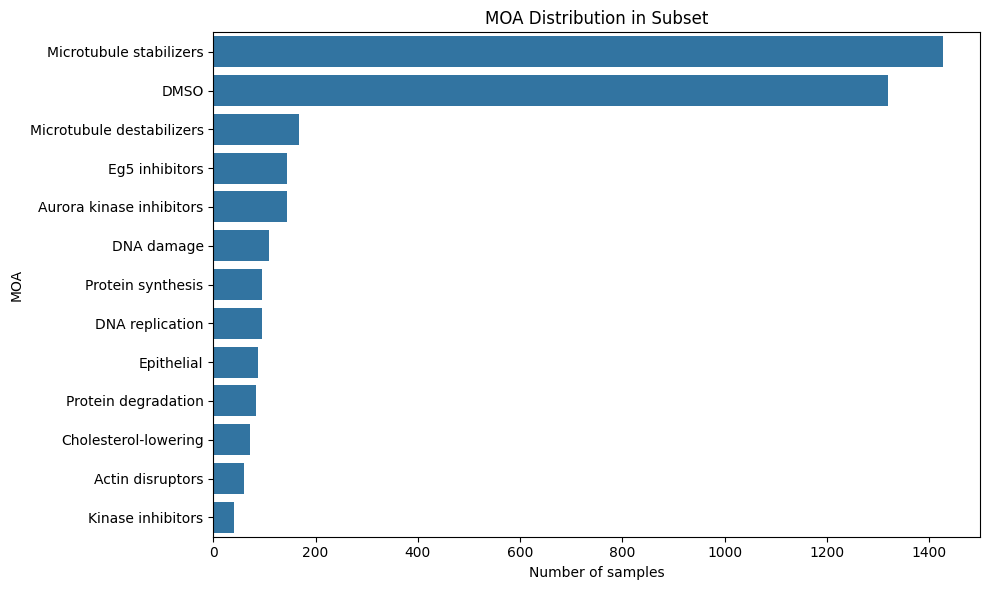

In [31]:
#Bar plot of MOA distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=full_meta, y="moa", order=full_meta["moa"].value_counts().index)
plt.title("MOA Distribution in Subset")
plt.xlabel("Number of samples")
plt.ylabel("MOA")

plt.tight_layout()
plt.savefig(r"results/figures/moa_distribution.png", dpi=300)
plt.show()

Conclusion: It doesnt look very balanced.

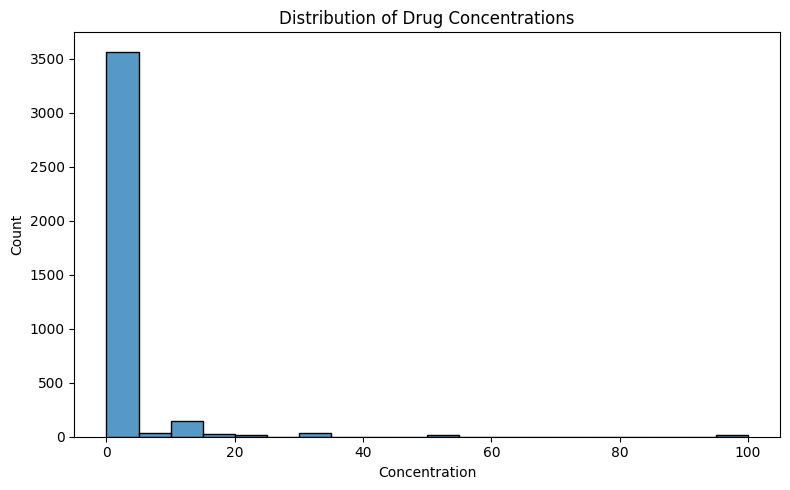

In [33]:
#Histogram of concentrations
plt.figure(figsize=(8,5))
sns.histplot(full_meta["concentration"], bins=20)
plt.title("Distribution of Drug Concentrations")
plt.xlabel("Concentration")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig(r"results/figures/concentration_histogram.png", dpi=300)
plt.show()

Conclusion : Not a very well spread dosing either

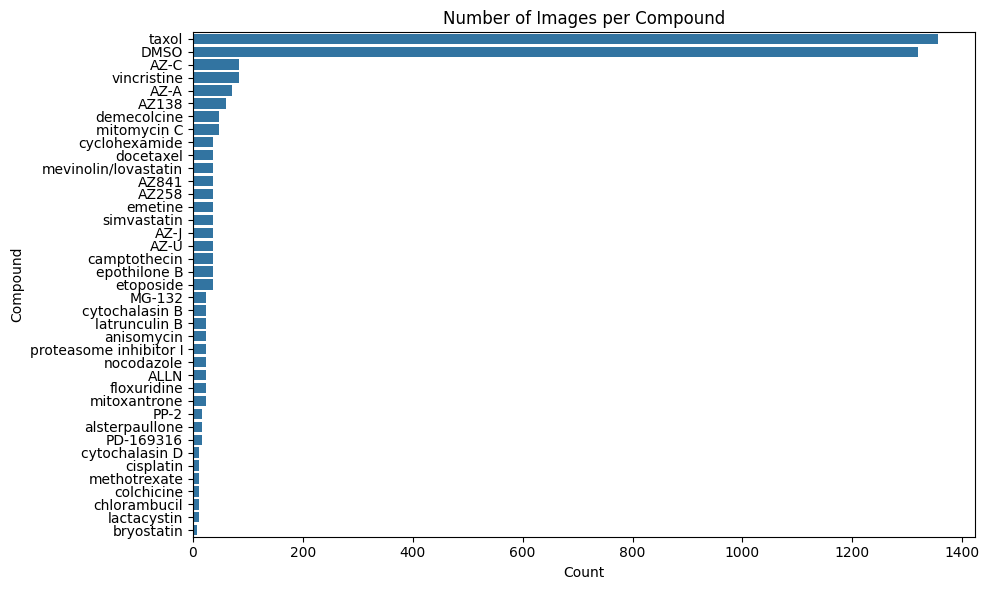

In [34]:
# Count per compound (bar plot)
compound_counts = full_meta["compound"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=compound_counts.values, y=compound_counts.index)
plt.title("Number of Images per Compound")
plt.xlabel("Count")
plt.ylabel("Compound")

plt.tight_layout()
plt.savefig(r"results/figures/compound_counts.png", dpi=300)
plt.show()

Conclusion : Shows data imbalance between compounds

In [35]:
import tifffile as tiff
import os
import matplotlib.pyplot as plt

row = full_meta.iloc[0]


base_dir = "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/raw"

paths = [
    os.path.join(base_dir, row["Image_PathName_DAPI"], row["Image_FileName_DAPI"]),
    os.path.join(base_dir, row["Image_PathName_Tubulin"], row["Image_FileName_Tubulin"]),
    os.path.join(base_dir, row["Image_PathName_Actin"], row["Image_FileName_Actin"])
]

print(paths[0])  # debug check

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/raw/Week1_22123/Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-9CC39666813B.tif


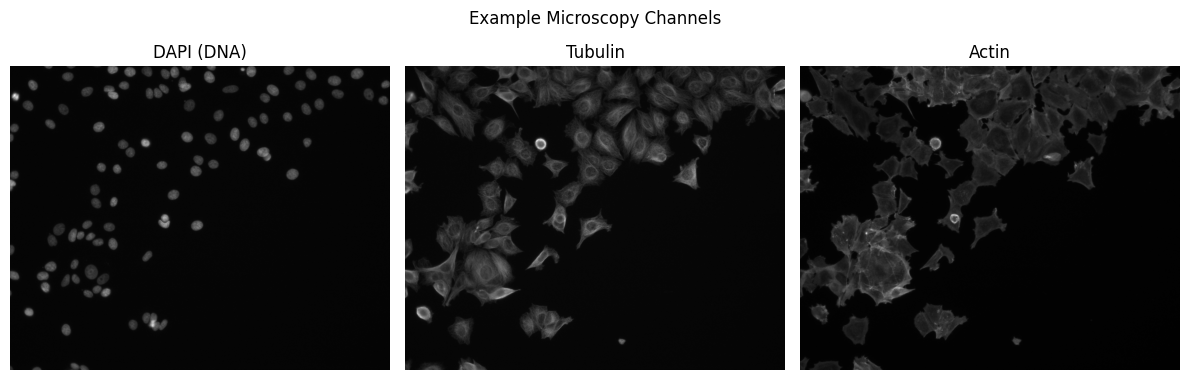

In [36]:
# Example images (5-channel or 3-channel)
import tifffile as tiff
import numpy as np

row = subset_metadata.iloc[0]

paths = [
    os.path.join(base_dir, row["Image_PathName_DAPI"], row["Image_FileName_DAPI"]),
    os.path.join(base_dir, row["Image_PathName_Tubulin"], row["Image_FileName_Tubulin"]),
    os.path.join(base_dir, row["Image_PathName_Actin"], row["Image_FileName_Actin"])
]

images = [tiff.imread(p) for p in paths]

fig, axes = plt.subplots(1,3, figsize=(12,4))

titles = ["DAPI (DNA)", "Tubulin", "Actin"]

for i in range(3):
    axes[i].imshow(images[i], cmap="gray")
    axes[i].set_title(titles[i])
    axes[i].axis("off")

plt.suptitle("Example Microscopy Channels")
plt.tight_layout()
plt.savefig(r"results/figures/example_channels.png", dpi=300)
plt.show()

These plots show the distribution of compounds, concentrations, and biological mechanisms of action (MOA) in the selected subset. Example microscopy images demonstrate the three fluorescent channels (DNA, tubulin, actin), highlighting morphological differences induced by drug treatments.

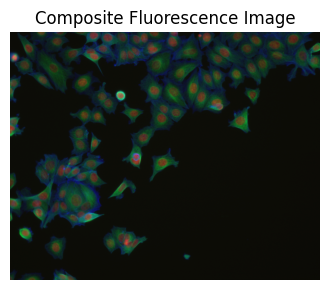

In [37]:
import numpy as np
import matplotlib.pyplot as plt

rgb = np.stack([
    images[0] / images[0].max(),   # DAPI
    images[1] / images[1].max(),   # Tubulin
    images[2] / images[2].max()    # Actin
], axis=-1)

plt.figure(figsize=(4,4))
plt.imshow(rgb)
plt.title("Composite Fluorescence Image")
plt.axis("off")
plt.savefig(r"results/figures/composite_example.png", dpi=300)
plt.show()

We visualize representative microscopy images from the BBBC021 dataset, showing three fluorescent channels: DAPI (nuclear DNA), Tubulin (microtubules), and Actin (cytoskeleton). These channels capture complementary morphological features that reflect cellular responses to different drug perturbations.

In [38]:
#Image intensity statistics (sanity check)
# Check if channels differ in brightness / noise.
import numpy as np
import tifffile as tiff


row = subset_metadata.iloc[0]
base_dir = "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/raw"
sample_path = os.path.join(base_dir, row["Image_PathName_DAPI"], row["Image_FileName_DAPI"]),


img = tiff.imread(sample_path)

print("Min:", img.min())
print("Max:", img.max())
print("Mean:", img.mean())
print("Std:", img.std())

Min: 384
Max: 14512
Mean: 975.275634765625
Std: 915.3671581826509


In [39]:
# for 3 chennels
paths = [
    os.path.join(base_dir, row["Image_PathName_DAPI"], row["Image_FileName_DAPI"]),
    os.path.join(base_dir, row["Image_PathName_Tubulin"], row["Image_FileName_Tubulin"]),
    os.path.join(base_dir, row["Image_PathName_Actin"], row["Image_FileName_Actin"])
]

for i, ch in enumerate(["DAPI","Tubulin","Actin"]):
    print(ch, img[i].mean(), img[i].std())

DAPI 1285.5625 1201.6667002932843
Tubulin 1313.0 1224.4954062796642
Actin 1339.2375 1252.0932547513182


Conclusion for Mean :
1. The three fluorescence channels are on a comparable intensity scale
2. No channel is drastically brighter or darker overall
3. Imaging exposure and staining are relatively balanced

Conclusion for Std dev:
1. All channels have similar dynamic range
2. None of the channels is extremely noisy or flat
3. Structural information (cells, nuclei, cytoskeleton) is present in each channel

Comparable pixel intensity distributions across DAPI, Tubulin, and Actin channels indicate consistent staining and acquisition conditions, suggesting that observed phenotypic differences primarily reflect biological variation rather than technical artifacts.

In [40]:
#Image shape & resolution distribution
#This ensures consistent resolution.

#for DAPI

shapes = []

image_paths_DAPI = [
     os.path.join(base_dir, row["Image_PathName_DAPI"], row["Image_FileName_DAPI"])
    for _, row in subset_metadata.iterrows()
]
for p in image_paths_DAPI[:100]:
    img = tiff.imread(p)
    shapes.append(img.shape)

pd.Series(shapes).value_counts()

,count
"(1024, 1280)",100


In [41]:
#for Tubulin

shapes = []

image_paths_Tubulin = [
     os.path.join(base_dir, fix_path(row["Image_PathName_Tubulin"]), row["Image_FileName_Tubulin"])
    for _, row in subset_metadata.iterrows()
]
for p in image_paths_Tubulin[:100]:
    img = tiff.imread(p)
    shapes.append(img.shape)

pd.Series(shapes).value_counts()

,count
"(1024, 1280)",100


In [42]:
#for Actin

shapes = []

image_paths_Actin = [
    os.path.join(base_dir, fix_path(row["Image_PathName_Actin"]), row["Image_FileName_Actin"])
    for _, row in subset_metadata.iterrows()
]
for p in image_paths_Actin[:100]:
    img = tiff.imread(p)
    shapes.append(img.shape)

pd.Series(shapes).value_counts()

,count
"(1024, 1280)",100


In [43]:
#Missing values in metadata
full_meta.isnull().sum()

,0
TableNumber,0
ImageNumber,0
Image_FileName_DAPI,0
Image_PathName_DAPI,0
Image_FileName_Tubulin,0
Image_PathName_Tubulin,0
Image_FileName_Actin,0
Image_PathName_Actin,0
plate,0
well,0


In [46]:
check = pd.read_csv("data/processed/metadata_with_moa.csv")
check.head()

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,plate,well,Replicate,compound,concentration,moa
0,1,11,Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-...,Week1_22123,Week1_150607_B04_s3_w2D81AEFB9-9DD4-4B59-9177-...,Week1_22123,Week1_150607_B04_s3_w408BE006A-BF34-457E-81A9-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
1,1,12,Week1_150607_B04_s4_w1EB720AD1-83BA-48A7-8C47-...,Week1_22123,Week1_150607_B04_s4_w261B79A05-7534-46F3-8C80-...,Week1_22123,Week1_150607_B04_s4_w49FF7E7B1-F049-4994-BCA2-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
2,1,9,Week1_150607_B04_s1_w11323931B-BDA7-4F42-870E-...,Week1_22123,Week1_150607_B04_s1_w2F8F7EA7A-EC57-49CA-A556-...,Week1_22123,Week1_150607_B04_s1_w494DCA5C4-3531-497D-A8B0-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
3,1,10,Week1_150607_B04_s2_w1F649C703-6FA8-406F-8575-...,Week1_22123,Week1_150607_B04_s2_w2802CC81E-56F9-41C5-A6C2-...,Week1_22123,Week1_150607_B04_s2_w4342F300D-60F8-4256-A637-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
4,1,251,Week1_150607_B04_s3_w1B0B8AAC7-F2AD-4756-939C-...,Week1_22141,Week1_150607_B04_s3_w25C7FD77E-FDC4-471F-A512-...,Week1_22141,Week1_150607_B04_s3_w42BD03411-D32F-4179-A6C5-...,Week1_22141,Week1_22141,B04,2,cytochalasin B,10.0,Actin disruptors


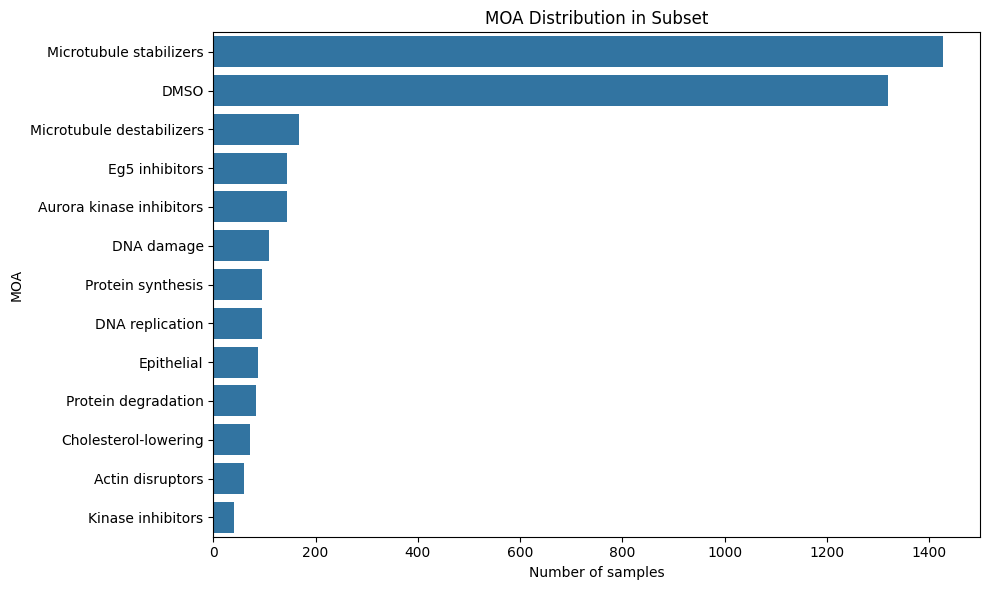

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=check, y="moa", order=check["moa"].value_counts().index)
plt.title("MOA Distribution in Subset")
plt.xlabel("Number of samples")
plt.ylabel("MOA")
plt.savefig(r"results/figures/moa_distribution.png", dpi=300)
plt.tight_layout()

plt.show()

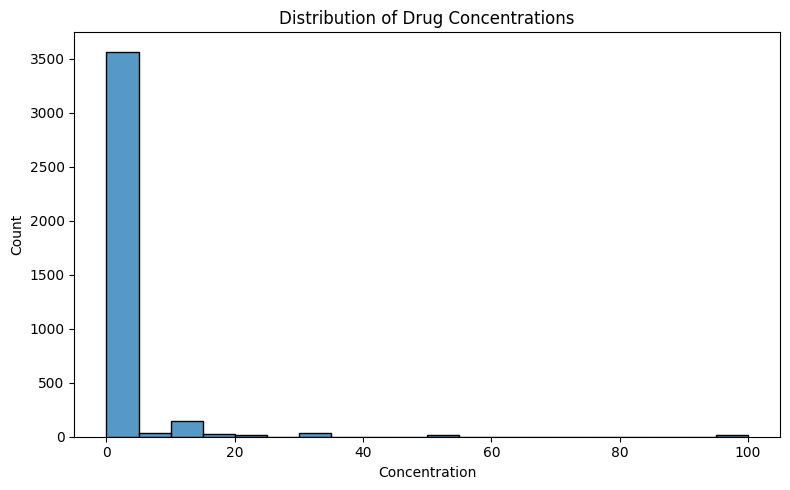

In [48]:
#Histogram of concentrations
plt.figure(figsize=(8,5))
sns.histplot(check["concentration"], bins=20)
plt.title("Distribution of Drug Concentrations")
plt.xlabel("Concentration")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

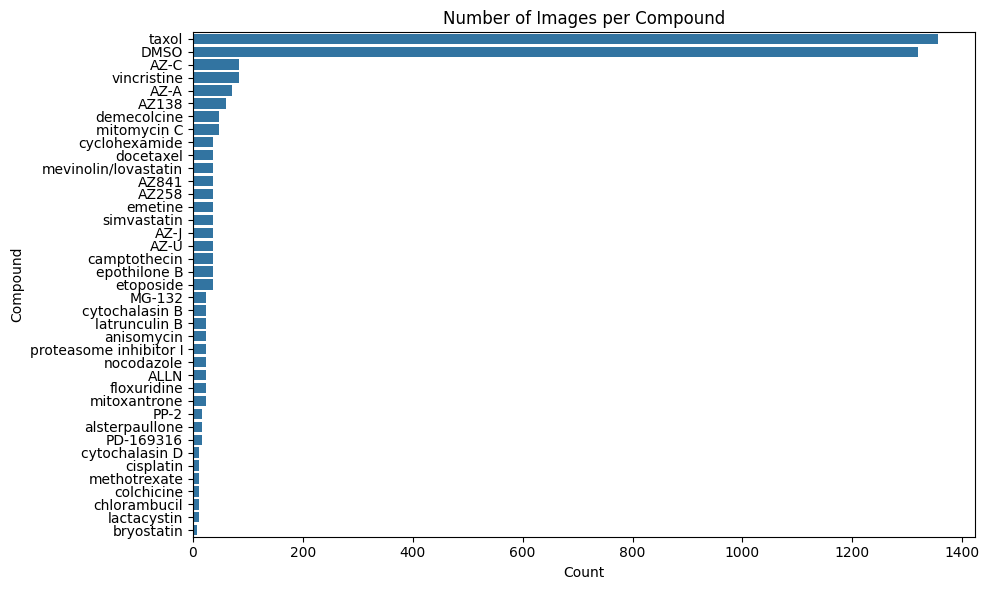

In [49]:
# Count per compound (bar plot)
compound_counts = check["compound"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=compound_counts.values, y=compound_counts.index)
plt.title("Number of Images per Compound")
plt.xlabel("Count")
plt.ylabel("Compound")

plt.tight_layout()

plt.show()

In [50]:
len(check)

3848